In [34]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path

In [68]:
#read chronos file
def time_reader(f, time_correction=False):
    f=open(f)
    lines = f.readlines()
    time_map = {} 
    #start datetime: {end datetime: e_dt, network latency per img: nw, 
    # compute latency per imd : comp, throughput: th, batch_size: bs, num_batches: nb, 
    # total_time: e_dt - start_dt, (apply day correction if required) 
    # network latency total: nw_t, compute latency total: comp_t, 
    # flop: fp, s_per_op: s*10**9/op, nw_std: 0, comp_std: 0 } 
    dt_st=0
    dt_et=0
    for line in lines:
        line=line.strip()
        if "startheat" in line:
            st = line.split("TIME:")[-1]
            dt_st = datetime.strptime(st, "%H:%M:%S.%f")
        if "FLOP count" in line:
            #this means it was successful (probably)
            #create dict object here
            # rank 0 FLOP count: 472055808 and full time*10**9 s/op: 0.3508
            flop = line.split("count: ")[-1].split(" and ")[0]
            s_per_op = line.split("s/op: ")[-1]
            time_map[dt_st] = {"e_dt":0, "nw":0, "comp":0, "th":0, "bs":0, "nb":0, "total_time":0, 
            "nw_t":0, "comp_t":0, "flop":int(flop), "s_per_op": float(s_per_op), "nw_std": 0, "comp_std": 0}
        elif "Time taken by rank:" in line:
            # Time taken by rank:0 in total(avg): 0.3312s on avg per image: 0.1656s with std: 0.0050s network time: 0.0798s 
            # and network std: 0.0798s network time per img: 0.0399 compute time: 0.1257s 
            # compute/network ratio: 1.5764 and throughput 6.0381 img/s
            nw_t = line.split("network time: ")[-1].split("s")[0]
            nw = line.split("network time per img: ")[-1].split("s")[0]
            nw_std = line.split("network std: ")[-1].split("s")[0]
            comp_t = line.split("total(avg): ")[-1].split("s")[0]
            comp = line.split("avg per image: ")[-1].split("s")[0]
            comp_std = line.split("with std: ")[-1].split("s")[0]
            th = line.split("throughput ")[-1].split(" ")[0]
            time_map[dt_st]["nw_t"] = nw_t
            time_map[dt_st]["nw"] =  nw
            time_map[dt_st]["nw_std"]=nw_std
            time_map[dt_st]["comp_t"] =comp_t
            time_map[dt_st]["comp"] = comp
            time_map[dt_st]["comp_std"]=comp_std
            time_map[dt_st]["th"]=th
        if "endheat" in line:
            et  = line.split("TIME:")[-1]
            if dt_st not in time_map:
                break
            dt_et = datetime.strptime(et, "%H:%M:%S.%f")
            time_map[dt_st]["e_dt"] = dt_et
    
    if dt_et==0 or dt_st==0:
        return None
    if time_correction:
        pass

         
    return time_map

#read heat file
def heat_reader(f, time_correction=False):
    f=open(f)
    lines=f.readlines()
    heat_map={}
    #{dt:{temp:t, volt:v, freq:f, throttled:t, total_volt: tv}}
    for l in range(len(lines)-2):
        line=lines[l]
        line=line.strip()
        # TIME:17:49:20
        # 32172
        # freq:frequency(48)=1400000000,throttle_flag:throttled=0x50000,voltage:volt=1.3500V,volt=1.2500V,volt=1.2500V,volt=1.2250V
        if "TIME:" in line:
            dt = datetime.strptime(line.split("TIME:")[-1], "%H:%M:%S")
            temp_line = lines[l+1].strip()
            # print("here?")
            if "TIME" not in temp_line and "freq" not in temp_line:
                temp = float(temp_line)/10**3
                freq_line = lines[l+2]
                if "volt" in freq_line:
                    freq = float(freq_line.split(",")[0].split("=")[-1])*10**-9
                    throttled = (freq_line.split(",")[1].split("=")[-1][-1] == "0")
                    volts = [ float(v.split("volt=")[-1].split("V")[0]) for v in freq_line.split("voltage:")[-1].split(",")]
                    heat_map[dt]={"temp":temp, "volt":volts[0], "freq":freq, "throttled": throttled, "total_volt":sum(volts)}
                else:
                    continue

            else:
                continue
    if time_correction:
        pass

    return heat_map



def tf_calc(w):
    y=0
    if w < 8:
        y = 0.157 - 0.004*27 + 0.075*w
    else:
        y = 0.667 - 0.008*27 + 0.023*w
    return y

#time sync/match chronos and heat file


0 0
319 28
0 0
28
291


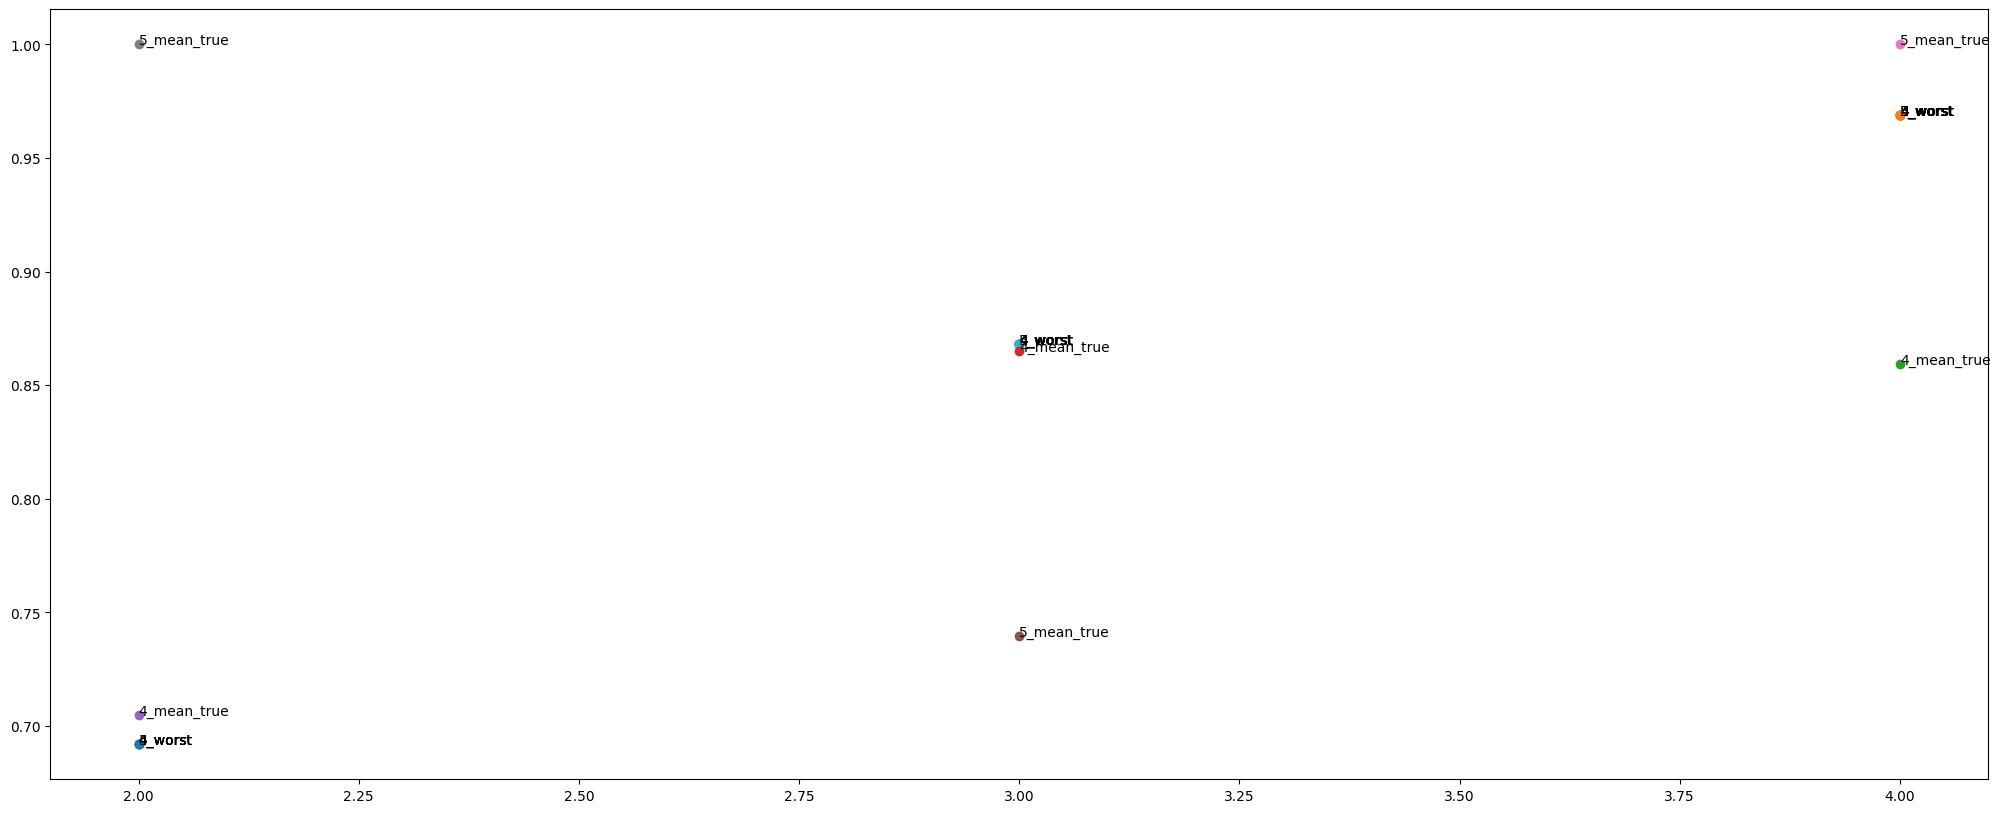

In [93]:
failure = {}
world_size_count = 0
world_size_5_count = 0
world_size_5_fail_count = 0
num_batch_size_10_count = 0
num_batch_size_10_fail_count = 0
batch_size_6_count = 0
batch_size_6_fail_count = 0
total_counter=0
throttle_map={}
# machines = [[1,2],[1,3],[1,4],[2,4],[2,5],[2,6],[4,3]]
machines = [[2,4], [2,5], [2,6]]
for m in machines:
    for mid in range(1,42): #device id in subcluster
        set_flag=False
        for world_size in [4,3,2,1]: #[4,2,1]: #number of layer splits/pipeline depth
            for batch_size in [4]: #[4,1]:#[1,4,6]:  #number of images in a batch per inference
                for num_batch in [10]:#[5,3,1] :#[1,10]: #number of batches per exp
                    counter=0
                    # failures = 
                    #try to sweep all possible files:
                    for trial in range(1,42):
                        # fname = f"../logs/snapshot_sweep/b-{m[0]}-{m[1]}/1_ranking_logs/{mid}_{world_size}_{batch_size}_{num_batch}_logs/" 
                        fname = f"../logs/trail_sweep/b-{m[0]}-{m[1]}/1_ranking_logs/{mid}_{world_size}_{batch_size}_{num_batch}_logs/" 
                        # fname = f"../logs/sweep/b-1-2/1_ranking_logs/{mid}_{world_size}_{batch_size}_{num_batch}_logs/" 
                        c_fname = f"{fname}/speed_chronosbramble-{m[0]}-{m[1]}-{trial}.log"
                        h_fname = f"{fname}/speed_heatbramble-{m[0]}-{m[1]}-{trial}.log"
                        if Path(c_fname).is_file() and Path(h_fname).is_file():
                            set_flag=True
                            # print("check")
                            # print(mid, world_size, batch_size, num_batch)
                            time_map = time_reader(c_fname)
                            total_counter+=1
                            # print(time_map!=None)
                            if world_size==5:
                                world_size_5_count+=1
                            if num_batch==10:
                                num_batch_size_10_count+=1
                            if batch_size==6:
                                batch_size_6_count+=1
                            if time_map==None:
                                failure[f"{m[0]}+{m[1]}+main_{mid}_{world_size}_{batch_size}_{num_batch}_worker_{trial}"] = (time_map==None)
                                if world_size==5:
                                    world_size_5_fail_count+=1
                                if num_batch==10:
                                    num_batch_size_10_fail_count+=1
                                if batch_size==6:
                                    batch_size_6_fail_count+=1
                            counter+=1
                            if time_map!=None:
                                heat_map = heat_reader(h_fname)
                                throttle_map[f"{m[0]}+{m[1]}+main_{mid}_{world_size}_{batch_size}_{num_batch}_worker_{trial}"] = {"total":len(heat_map), 
                                "throttled":sum([1 for i in heat_map if heat_map[i]["throttled"]])} 
                            #for k in heat_map.keys():

                                # if heat_map[k]["temp"] > 60:
                                #     print("heat throttled?")
                                # if heat_map[k]["throttled"]:
                                #     print(heat_map[k]["volt"], heat_map[k]["total_volt"])
                            # print(heat_map)
                            # print(h_fname)
                            # break
                        if counter==world_size:
                            break
        # if set_flag:
        #     break
# print(failure.keys())
print(world_size_5_count, world_size_5_fail_count)
print(num_batch_size_10_count, num_batch_size_10_fail_count)
print(batch_size_6_count, batch_size_6_fail_count)
print(len(failure))
print(total_counter-len(failure))

# print(throttle_map)
fig, axs = plt.subplots(figsize=(25,10))
true_y=[]
avg_true_y_map = {}
# old_m2 = 
for t in throttle_map:
    main = int(t.split("_")[1])
    world = int(t.split("_")[2])
    num_batch = int(t.split("_")[4])
    # world = int(t.split("_")[4])
    
    # print(t)
    m1,m2,_ = t.split("+")
    if (len(true_y)==old_world) and (m2!=old_m2 or world!=old_world):#(m2!=old_m2 or main!=old_main or world!=old_world):
        y=[tf_calc(w) for w in range(old_world)]
        # worst_y = sum(y) + max(y)*(num_batch-len(y))
        worst_y = np.mean(y)*(num_batch-len(y))
        axs.scatter(old_world, worst_y)
        # axs.scatter(old_world, max(true_y))
        if m2 not in avg_true_y_map:
            avg_true_y_map[m2] = {}
        if old_world not in avg_true_y_map[m2]:
            avg_true_y_map[m2][old_world]=[]
        avg_true_y_map[m2][old_world].append(max(true_y))
        # avg_true_y_map[m2][old_world].extend(true_y)
        # axs.text(old_world, max(true_y), f"{old_m2}_max_true")
        axs.text(old_world, worst_y, f"{old_m2}_worst")
        true_y=[]
    old_m2 = m2
    old_main=main
    old_world=world
    true_y.append(throttle_map[t]["throttled"]/throttle_map[t]["total"])
    # m2 = m2.split("main")[0]
    # print(m1,m2, worst_y, true_y, true_y/worst_y)
    # axs.scatter(world, worst_y)
    # axs.scatter(world, true_y)
    # axs.text(world, true_y, f"{m2}_true")
    # axs.text(world, worst_y, f"{m2}_worst")

for m2 in avg_true_y_map:
    for world in avg_true_y_map[m2]:
        axs.scatter(world, np.mean(avg_true_y_map[m2][world]))
        axs.text(world, np.mean(avg_true_y_map[m2][world]), f"{m2}_mean_true")
    

#  = (x < 8)[0.157 − 0.004 avail devs + 0.075x]+
# (x ≥ 8)[0.667 − 0.008 avail devs + 0.023x


# time_reader("../logs/sweep/b-1-2/1_ranking_logs/13_2_6_10_logs/speed_chronosbramble-1-2-13.log")